In [27]:
import pandas as pd
import numpy as np

In [28]:
data=pd.read_csv("Agriculture_pricet.csv")

In [29]:
display(data.head())

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


In [30]:
data.shape

(737392, 10)

In [31]:
data.info

<bound method DataFrame.info of                 STATE District Name                      Market Name  \
0         Maharashtra        nashik                Lasalgaon(Niphad)   
1         Maharashtra        satara                            Patan   
2       Uttar Pradesh      mainpuri                            Bewar   
3           Rajasthan   chittorgarh                        Nimbahera   
4           Rajasthan    pratapgarh                       Pratapgarh   
...               ...           ...                              ...   
737387      Tamilnadu      namakkal  Kumarapalayam(Uzhavar Sandhai )   
737388         Orissa     dhenkanal                    Kamakhyanagar   
737389      Tamilnadu      dindigul    Vedasanthur(Uzhavar Sandhai )   
737390      Tamilnadu  virudhunagar   Virudhunagar(Uzhavar Sandhai )   
737391        Haryana  yamuna nagar                      Chhachrauli   

       Commodity           Variety    Grade  Min_Price  Max_Price  \
0          Wheat  Maharashtra 2189

In [32]:
data.describe()

,Min_Price,Max_Price,Modal_Price
count,737392.000000,737392.000000,737392.000000
mean,2204.849862,2659.733824,2474.484638
std,1920.977696,2145.250773,2023.851909
min,0.000000,0.000000,0.000000
25%,1100.000000,1500.000000,1300.000000
50%,2000.000000,2300.000000,2150.000000
75%,2700.000000,3205.000000,3000.000000
max,420000.000000,480000.000000,460000.000000


In [33]:
data[['Min_Price','Max_Price','Modal_Price']].describe()

,Min_Price,Max_Price,Modal_Price
count,737392.000000,737392.000000,737392.000000
mean,2204.849862,2659.733824,2474.484638
std,1920.977696,2145.250773,2023.851909
min,0.000000,0.000000,0.000000
25%,1100.000000,1500.000000,1300.000000
50%,2000.000000,2300.000000,2150.000000
75%,2700.000000,3205.000000,3000.000000
max,420000.000000,480000.000000,460000.000000


In [34]:
#data cleaning
data.isna().sum()
#no null values

STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
dtype: int64

In [35]:
#check dupliates
data.duplicated().sum()
#no duplicates

0

In [36]:
data[(data['Min_Price'] > data['Modal_Price']) | 
     (data['Modal_Price'] > data['Max_Price'])]
#here shows min_price is greater than modal price,imposible in real market
#model price greater than maximum price

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
208,Madhya Pradesh,gwalior,Lashkar,Wheat,Mill Quality,FAQ,2245.0,0.0,2255.0,6/6/2023
961,Uttar Pradesh,sonbhadra,Dudhi,Onion,Onion,FAQ,800.0,0.0,900.0,6/6/2023
1414,Uttar Pradesh,sonbhadra,Dudhi,Potato,Other,FAQ,900.0,0.0,1000.0,6/6/2023
1821,Uttar Pradesh,sonbhadra,Dudhi,Tomato,Deshi,FAQ,900.0,0.0,1000.0,6/6/2023
1913,Uttar Pradesh,sonbhadra,Dudhi,Tomato,Deshi,FAQ,1000.0,0.0,1100.0,6/7/2023
...,...,...,...,...,...,...,...,...,...,...
690496,Kerala,idukki,Nedumkandam,Potato,Other,FAQ,3000.0,0.0,3000.0,5/3/2025
693293,Kerala,malappuram,Manjeri,Onion,Other,FAQ,1750.0,0.0,1800.0,5/6/2025
718124,Kerala,alappuzha,Aroor,Onion,Big,FAQ,2200.0,0.0,2300.0,5/26/2025
721030,Kerala,ernakulam,Broadway market,Onion,1st Sort,Non-FAQ,2200.0,0.0,2400.0,5/28/2025


In [42]:
data = data[
    (data['Min_Price'] <= data['Modal_Price']) &
    (data['Modal_Price'] <= data['Max_Price'])
]
display(data.head())

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,day,month,year
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6,6,2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6,6,2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6,6,2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6,6,2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6,6,2023


In [43]:
print(data.columns.tolist())

['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'day', 'month', 'year']


In [40]:
data[data['Price Date'].isna()]
#check the failure dates

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date


In [ ]:
data['day'] = data['Price Date'].dt.day
data['month'] = data['Price Date'].dt.month
data['year'] = data['Price Date'].dt.year

data.drop('Price Date', axis=1, inplace=True)


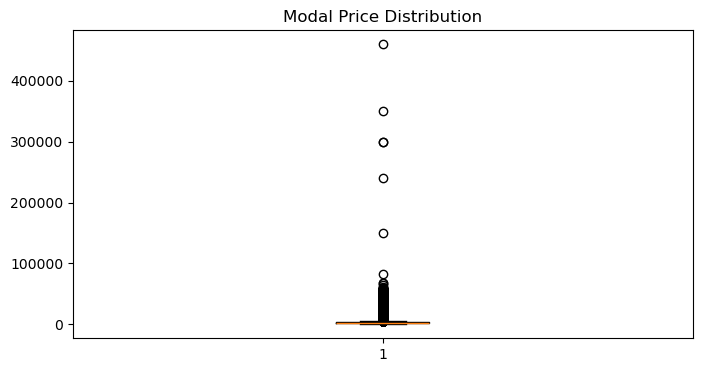

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(data['Modal_Price'])
plt.title("Modal Price Distribution")
plt.show()


In [47]:
Q1 = data['Modal_Price'].quantile(0.25)
Q3 = data['Modal_Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


(-1250.0, 5550.0)

In [48]:
price_cols = ['Min_Price', 'Modal_Price', 'Max_Price']

for col in price_cols:
    data[col] = data[col].clip(lower_bound, upper_bound)


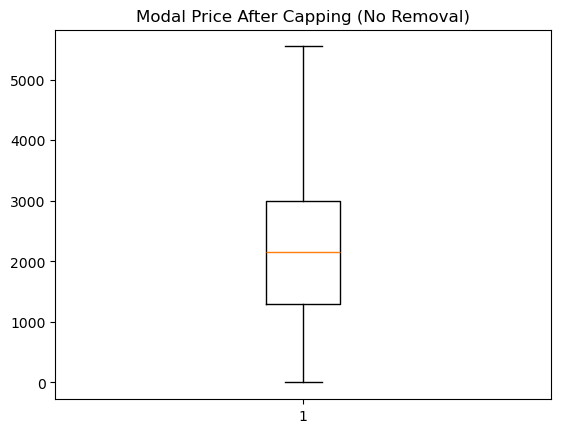

In [49]:
import matplotlib.pyplot as plt
plt.boxplot(data['Modal_Price'])
plt.title("Modal Price After Capping (No Removal)")
plt.show()


Lower Bound: -1250.0
Upper Bound: 5550.0
Invalid rows after capping: 0


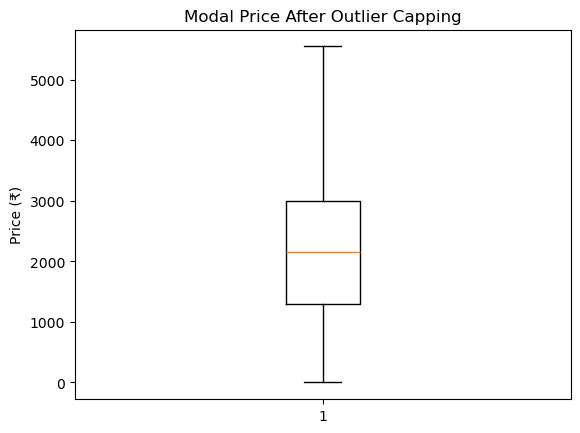

In [50]:
import pandas as pd

# Compute IQR using Modal_Price 
Q1 = data['Modal_Price'].quantile(0.25)
Q3 = data['Modal_Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Cap Modal_Price 
data['Modal_Price'] = data['Modal_Price'].clip(
    lower=lower_bound,
    upper=upper_bound
)

#  Cap Min_Price and Max_Price using SAME bounds 
data['Min_Price'] = data['Min_Price'].clip(
    lower=lower_bound,
    upper=upper_bound
)

data['Max_Price'] = data['Max_Price'].clip(
    lower=lower_bound,
    upper=upper_bound
)

# Enforce logical price consistency
# Ensure: Min_Price <= Modal_Price <= Max_Price
data['Min_Price'] = data[['Min_Price', 'Modal_Price']].min(axis=1)
data['Max_Price'] = data[['Max_Price', 'Modal_Price']].max(axis=1)

#  Final validation (should return 0 rows) 
invalid_rows = data[
    (data['Min_Price'] > data['Modal_Price']) |
    (data['Modal_Price'] > data['Max_Price'])
]

print("Invalid rows after capping:", invalid_rows.shape[0])
#  Optional visualization
import matplotlib.pyplot as plt
plt.boxplot(data['Modal_Price'])
plt.title("Modal Price After Outlier Capping")
plt.ylabel("Price (₹)")
plt.show()


In [53]:
#after preprocessing to save the dataset 
data.to_csv("clean_agri_prices.csv")

In [54]:
#To load the dataset after apply the preprocessing
df=pd.read_csv("clean_agri_prices.csv")

In [55]:
display(df.head())

,Unnamed: 0,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,day,month,year
0,0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6,6,2023
1,1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6,6,2023
2,2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6,6,2023
3,3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6,6,2023
4,4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6,6,2023


In [56]:
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [57]:
TARGET_COL = "Modal_Price"
PRICE_COLS = [
    "Min_Price",
    "Max_Price",
    "Modal_Price"
]

In [58]:
X = df.drop(columns=PRICE_COLS)
y = df[TARGET_COL]

In [59]:
assert X.select_dtypes(include=['object']).shape[1] == 0, \
    "Categorical columns not encoded properly"
#assert is a safety check,if the condition is false,stop the program and show the error message

AssertionError: Categorical columns not encoded properly

In [60]:
X.select_dtypes(include=['object']).columns

Index(['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade'],
      dtype='object')

In [61]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


In [62]:
assert X.select_dtypes(include=['object']).shape[1] == 0, \
    "Categorical columns not encoded properly"
#protect from accidental mistakes,ensure encoding,high accuracy

In [63]:
assert X.isnull().sum().sum() == 0, "Missing values in features"
assert y.isnull().sum() == 0, "Missing values in target"


In [64]:
FEATURE_COLUMNS = X.columns.tolist()

In [65]:
import joblib
joblib.dump(FEATURE_COLUMNS, "feature_schema.pkl")

['feature_schema.pkl']

In [71]:
cat_cols = [
    'STATE',
    'District Name',
    'Market Name',
    'Commodity',
    'Variety',
    'Grade'
]


In [73]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [102]:
import joblib
joblib.dump(label_encoders, "label_encoders.pkl")


['label_encoders.pkl']

In [74]:
print(df[cat_cols].head())
print(df[cat_cols].dtypes)


   STATE  District Name  Market Name  Commodity  Variety  Grade
0     17            254          845          4       58      0
1     17            312         1127          3       69      0
2     27            222          212          1       49      0
3     23             78         1057          4       69      0
4     23            279         1183          0       69      0
STATE            int32
District Name    int32
Market Name      int32
Commodity        int32
Variety          int32
Grade            int32
dtype: object


In [75]:
assert df.select_dtypes(include=['object']).shape[1] == 0

In [76]:
print(X.columns.tolist())

['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'day', 'month', 'year']


In [77]:
X = df[
    ['STATE', 'District Name', 'Market Name',
     'Commodity', 'Variety', 'Grade',
     'day', 'month', 'year']
]

y = df['Modal_Price']


In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [68]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (588425, 9)
X_test : (147107, 9)
y_train: (588425,)
y_test : (147107,)


In [82]:
print(X.shape)   # should be (rows, 9)
print(y.shape)   # should be (rows,)


(735532, 9)
(735532,)


In [81]:
assert 'Min_Price' not in X.columns
assert 'Max_Price' not in X.columns
assert 'Modal_Price' not in X.columns


In [84]:
print(data.columns.tolist())


['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'day', 'month', 'year']


In [85]:
print(data[cat_cols].dtypes)


STATE            int32
District Name    int32
Market Name      int32
Commodity        int32
Variety          int32
Grade            int32
dtype: object


In [86]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=80,
    max_depth=18,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=1
)

rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=18, min_samples_leaf=5, n_estimators=80,
                      n_jobs=1, random_state=42)

In [87]:
#predict
rf_pred = rf_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print("Random Forest MAE (₹):", rf_mae)
print("Random Forest R²:", rf_r2)


Random Forest MAE (₹): 202.079687227659
Random Forest R²: 0.8471577046422312


In [27]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb_model.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [28]:
gb_pred = gb_model.predict(X_test)


In [29]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2  = r2_score(y_test, gb_pred)

print("Gradient Boosting MAE (₹):", gb_mae)
print("Gradient Boosting R²:", gb_r2)


Gradient Boosting MAE (₹): 556.7917489708852
Gradient Boosting R²: 0.620912128647669


In [30]:
from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators=60,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=2
)

et_model.fit(X_train, y_train)


ExtraTreesRegressor(max_depth=20, min_samples_leaf=5, n_estimators=60, n_jobs=2,
                    random_state=42)

In [31]:
et_pred = et_model.predict(X_test)


In [32]:
et_mae = mean_absolute_error(y_test, et_pred)
et_r2  = r2_score(y_test, et_pred)

print("Extra Trees MAE (₹):", et_mae)
print("Extra Trees R²:", et_r2)


Extra Trees MAE (₹): 224.22060094418757
Extra Trees R²: 0.8438048629208015


In [33]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "Extra Trees"],
    "MAE (₹)": [rf_mae, gb_mae, et_mae],
    "R² Score": [rf_r2, gb_r2, et_r2]
})

results_df


,Model,MAE (₹),R² Score
0,Random Forest,202.079687,0.847158
1,Gradient Boosting,556.791749,0.620912
2,Extra Trees,224.220601,0.843805


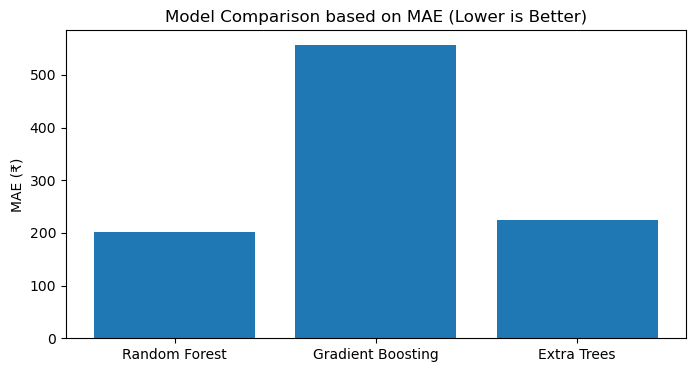

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(results_df["Model"], results_df["MAE (₹)"])
plt.title("Model Comparison based on MAE (Lower is Better)")
plt.ylabel("MAE (₹)")
plt.show()


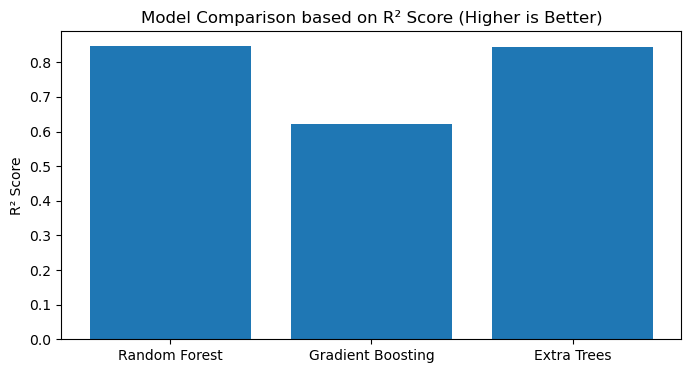

In [36]:
plt.figure(figsize=(8,4))
plt.bar(results_df["Model"], results_df["R² Score"])
plt.title("Model Comparison based on R² Score (Higher is Better)")
plt.ylabel("R² Score")
plt.show()


In [37]:
best_model = results_df.sort_values("MAE (₹)").iloc[0]
best_model
#MAE shows average price error in rupees it achieved the lowest MAE,which is more relavent for accuret
#price recommendation than variance

Model       Random Forest
MAE (₹)        202.079687
R² Score         0.847158
Name: 0, dtype: object

In [89]:
alpha = None
beta = None

In [90]:
import numpy as np

valid_data = df[
    (df['Modal_Price'].notna()) &
    (df['Min_Price'].notna()) &
    (df['Max_Price'].notna()) &
    (df['Modal_Price'] > 1) &     # strictly > 1
    (df['Min_Price'] > 0) &
    (df['Max_Price'] > 0)
].copy()


In [91]:
valid_data['min_ratio'] = valid_data['Min_Price'] / valid_data['Modal_Price']
valid_data['max_ratio'] = valid_data['Max_Price'] / valid_data['Modal_Price']

valid_data = valid_data[
    np.isfinite(valid_data['min_ratio']) &
    np.isfinite(valid_data['max_ratio'])
]

In [92]:
alpha = valid_data['min_ratio'].median()
beta  = valid_data['max_ratio'].median()

print("Alpha:", alpha)
print("Beta :", beta)


Alpha: 0.9420289855072463
Beta : 1.0434782608695652


In [93]:
pred_modal = rf_model.predict(X_test)

pred_min = pred_modal * alpha
pred_max = pred_modal * beta


In [94]:
import numpy as np
pred_min = np.minimum(pred_min, pred_modal)
pred_max = np.maximum(pred_max, pred_modal)


In [95]:
final_predictions = pd.DataFrame({
    "Predicted_Modal_Price": pred_modal,
    "Estimated_Min_Price": pred_min,
    "Estimated_Max_Price": pred_max
})

final_predictions.head()


,Predicted_Modal_Price,Estimated_Min_Price,Estimated_Max_Price
0,5548.619095,5226.960017,5789.863403
1,4972.433725,4684.176697,5188.626495
2,1686.999103,1589.202053,1760.346890
3,2651.704517,2497.982516,2766.996018
4,2521.263298,2375.103107,2630.883441


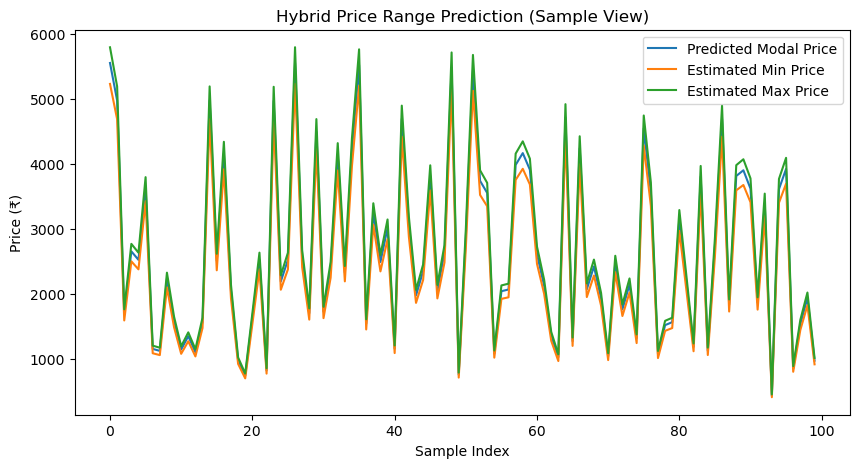

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Predict modal prices using final Random Forest model
pred_modal = rf_model.predict(X_test)

# Hybrid estimation
pred_min = pred_modal * alpha
pred_max = pred_modal * beta

# Safety enforcement
pred_min = np.minimum(pred_min, pred_modal)
pred_max = np.maximum(pred_max, pred_modal)

# Take a small sample for clear visualization
sample_size = 100
x_axis = np.arange(sample_size)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, pred_modal[:sample_size], label="Predicted Modal Price")
plt.plot(x_axis, pred_min[:sample_size], label="Estimated Min Price")
plt.plot(x_axis, pred_max[:sample_size], label="Estimated Max Price")

plt.title("Hybrid Price Range Prediction (Sample View)")
plt.xlabel("Sample Index")
plt.ylabel("Price (₹)")
plt.legend()
plt.show()


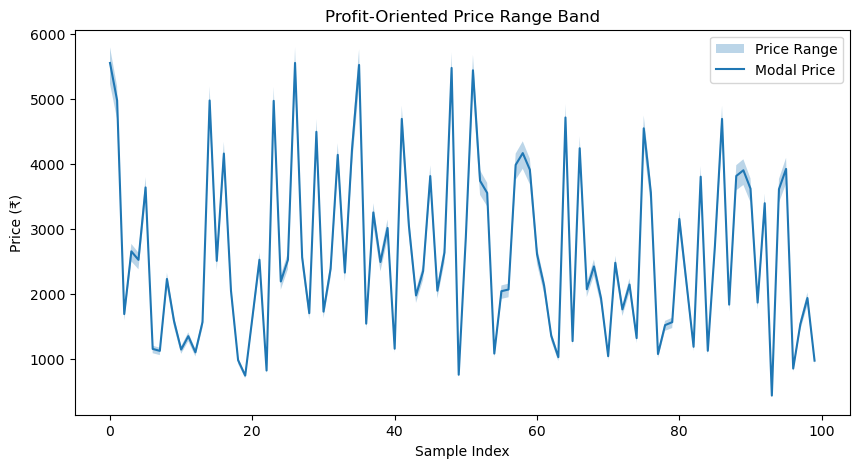

In [97]:
plt.figure(figsize=(10, 5))
plt.fill_between(
    x_axis,
    pred_min[:sample_size],
    pred_max[:sample_size],
    alpha=0.3,
    label="Price Range"
)
plt.plot(x_axis, pred_modal[:sample_size], label="Modal Price")

plt.title("Profit-Oriented Price Range Band")
plt.xlabel("Sample Index")
plt.ylabel("Price (₹)")
plt.legend()
plt.show()


In [103]:
import joblib

# Save trained Random Forest model
joblib.dump(rf_model, "rf_price_model1.pkl")

# Save hybrid ratios
joblib.dump(alpha, "alpha.pkl")
joblib.dump(beta, "beta.pkl")

# Save feature schema (order matters!)
joblib.dump(X_train.columns.tolist(), "feature_schema.pkl")
print("✅ Model and artifacts saved successfully")

✅ Model and artifacts saved successfully


In [104]:
rf_loaded = joblib.load("rf_price_model1.pkl")
alpha_loaded = joblib.load("alpha.pkl")
beta_loaded = joblib.load("beta.pkl")
features_loaded = joblib.load("feature_schema.pkl")

print("Loaded features:", features_loaded)


Loaded features: ['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'day', 'month', 'year']


In [105]:
print(X.columns.tolist())


['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'day', 'month', 'year']


In [106]:
label_encoders['District Name'].classes_


array(['adilabad', 'agra', 'ahmedabad', 'ahmednagar', 'ajmer', 'akola',
       'alappuzha', 'aligarh', 'alipurduar', 'alirajpur', 'alwar',
       'amarawati', 'ambala', 'ambedkarnagar', 'amethi', 'amreli',
       'amritsar', 'amroha', 'anand', 'anantnag', 'angul', 'anupur',
       'araria', 'auraiya', 'aurangabad', 'ayodhya', 'azamgarh', 'badaun',
       'bagalkot', 'baghpat', 'bahraich', 'balaghat', 'ballia',
       'balrampur', 'banda', 'bangalore', 'banka', 'bankura', 'barabanki',
       'baran', 'bareilly', 'bargarh', 'barnala', 'basti', 'beed',
       'belgaum', 'bellary', 'betul', 'bhadrak', 'bhandara', 'bharatpur',
       'bharuch', 'bhavnagar', 'bhilwara', 'bhind', 'bhiwani', 'bhojpur',
       'bhopal', 'bidar', 'bijapur', 'bijnor', 'bikaner', 'bilaspur',
       'birbhum', 'bishnupur', 'bulandshahar', 'bundi', 'burhanpur',
       'buxar', 'chamba', 'champawat', 'chandauli', 'chandigarh',
       'chandrapur', 'chhatarpur', 'chhindwara', 'chikmagalur',
       'chitradurga', 'chit